### Các câu hỏi phân tích
1. Phân phối doanh thu (revenue) của các đơn hàng trông như thế nào? → cần biểu đồ đơn biến số
2. Số lượng đơn hàng phân bổ ra sao giữa các category? → cần biểu đồ phân loại
3. Số lượng sản phẩm mua (quantity) có liên quan đến doanh thu (revenue) không? → cần biểu đồ hai biến số-số
4. Doanh thu có khác biệt giữa các region không? → cần biểu đồ so sánh số-phân loại

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("LAB06_09_cleaned_retail_sample.csv")
df.head()

,order_id,order_date,customer_id,gender,region,category,product,quantity,unit_price,discount,customer_age,status,order_month,revenue,age_group
0,O001,2025-01-03,C001,male,North,Technology,Laptop,1,1250.0,0.05,35.0,Delivered,2025-01,1187.50,36-50
1,O002,2025-01-05,C002,male,South,Furniture,Office Chair,2,180.0,0.10,42.0,Delivered,2025-01,324.00,36-50
2,O003,2025-01-07,C003,male,North,Office Supplies,Printer Paper,5,12.5,0.00,NaN,Delivered,2025-01,62.50,Unknown
3,O004,2025-01-09,C004,female,Central,Technology,Headset,3,45.0,0.05,29.0,Delayed,2025-01,128.25,26-35
4,O005,2025-01-11,C005,female,South,Furniture,Desk,1,350.0,0.15,31.0,Delivered,2025-01,297.50,26-35


## Biểu đồ 1: Đơn biến số (Univariate numeric) — trả lời câu hỏi 1


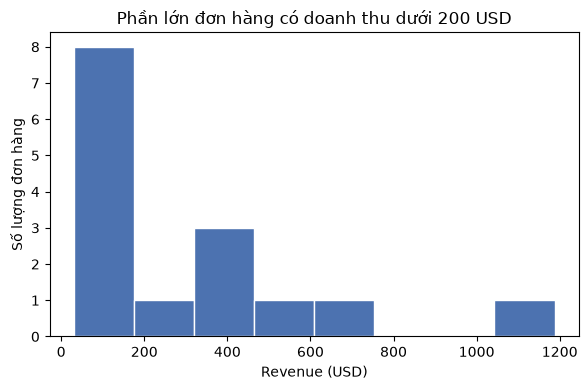

In [2]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(df["revenue"], bins=8, color="#4C72B0", edgecolor="white")
ax.set_title("Phần lớn đơn hàng có doanh thu dưới 200 USD")
ax.set_xlabel("Revenue (USD)")
ax.set_ylabel("Số lượng đơn hàng")
plt.tight_layout()
plt.show()

* Lý do chọn: revenue là biến số liên tục, histogram là cách chuẩn để xem hình dạng phân phối (lệch phải hay chuẩn, có outlier không).
* Diễn giải: phần lớn đơn hàng nằm trong khoảng doanh thu thấp (dưới ~200 USD), có vài đơn giá trị cao (như đơn laptop ~1187 USD) kéo dài đuôi phân phối sang phải.

## Biểu đồ 2: Phân loại (Categorical) — trả lời câu hỏi 2

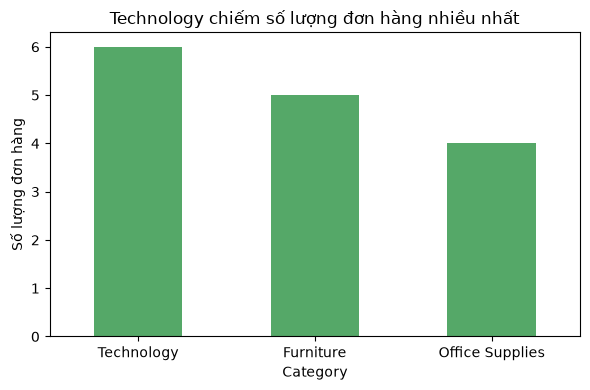

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
df["category"].value_counts().plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Technology chiếm số lượng đơn hàng nhiều nhất")
ax.set_xlabel("Category")
ax.set_ylabel("Số lượng đơn hàng")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

* Lý do chọn: category là biến phân loại, bar chart/countplot là lựa chọn chuẩn để so sánh tần suất giữa các nhóm.
* Diễn giải: Technology có 6 đơn hàng, Furniture 5, Office Supplies 4 — phân bổ khá đồng đều, không nhóm nào áp đảo tuyệt đối.

## Biểu đồ 3: Hai biến số-số (Bivariate numeric-numeric) — trả lời câu hỏi 3

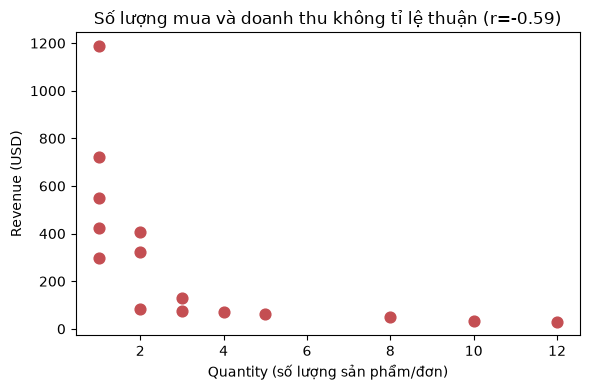

In [4]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(df["quantity"], df["revenue"], s=60, color="#C44E52")
corr = df[["quantity","revenue"]].corr().iloc[0,1]
ax.set_title(f"Số lượng mua và doanh thu không tỉ lệ thuận (r={corr:.2f})")
ax.set_xlabel("Quantity (số lượng sản phẩm/đơn)")
ax.set_ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()

* Lý do chọn: cả hai đều là biến số → scatter plot là công cụ chuẩn để xem mối quan hệ tuyến tính.
* Diễn giải: (chạy code để lấy giá trị r thật rồi viết theo kết quả) — dữ liệu gợi ý các đơn hàng số lượng lớn (như 10-12 sản phẩm) lại thường có đơn giá thấp (giấy, notebook) nên tổng doanh thu không cao; ngược lại đơn hàng revenue cao nhất chỉ mua 1 sản phẩm nhưng đơn giá rất lớn (laptop). Đây là điểm khác biệt thú vị so với unit_price vs revenue ở LAB06 (tương quan rất mạnh).

## Biểu đồ 4: So sánh Số-Phân loại (Numeric-categorical) — trả lời câu hỏi 4

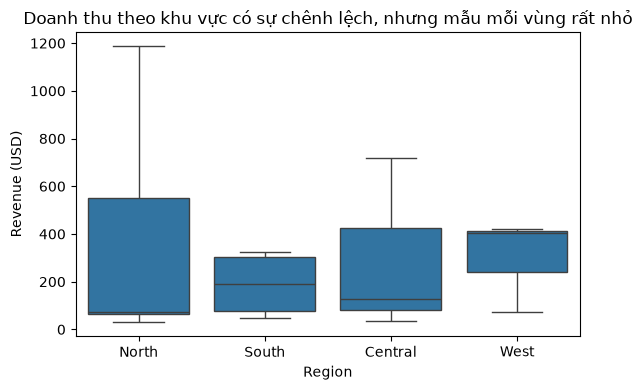

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x="region", y="revenue", ax=ax)
ax.set_title("Doanh thu theo khu vực có sự chênh lệch, nhưng mẫu mỗi vùng rất nhỏ")
ax.set_xlabel("Region")
ax.set_ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()

* Lý do chọn: so sánh 1 biến số (revenue) theo 1 biến phân loại (region) → boxplot phù hợp hơn bar chart vì thể hiện được cả phân tán/outlier, không chỉ giá trị trung bình.
* Diễn giải: một số vùng có khoảng dao động doanh thu rộng hơn (do có đơn giá trị lớn), nhưng cần xem kỹ số lượng mẫu trước khi kết luận.

## Biểu đồ bổ sung

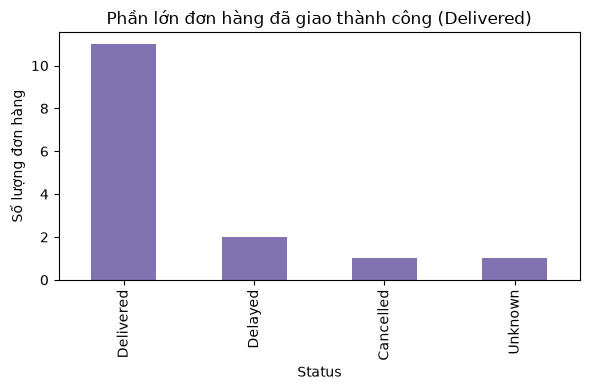

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
df["status"].value_counts().plot(kind="bar", ax=ax, color="#8172B2")
ax.set_title("Phần lớn đơn hàng đã giao thành công (Delivered)")
ax.set_xlabel("Status")
ax.set_ylabel("Số lượng đơn hàng")
plt.tight_layout()
plt.show()

| Câu hỏi | Loại biến | Biểu đồ đã chọn | Lý do |
|---|---|---|---|
| Phân phối revenue | Numeric | Histogram | Xem hình dạng phân phối 1 biến số |
| Số đơn theo category | Categorical | Bar chart | So sánh tần suất giữa các nhóm |
| Quantity vs Revenue | Numeric-Numeric | Scatter | Kiểm tra mối quan hệ tuyến tính |
| Revenue theo region | Numeric-Categorical | Boxplot | So sánh phân bố, không chỉ trung bình, giữa các nhóm |